# Declaration of Originality

**School of Informatics & IT**
<br/>**Diploma in Applied Artificial Intelligence**
<br/>**Machine Learning for Developers (CAI2C08)**
<br/>**AY2026/2027 April Semester**
<br/>**Program Codes**

* Student Name: Ayden Lum



**Declaration of Originality**
* I am the originator of this work, and I have appropriately acknowledged all other original sources used as my references for this work.
* I understand that Plagiarism is the act of taking and using the whole or any part of another person’s work, including work generated by AI, and presenting it as my own.
* I understand that Plagiarism is an academic offence and if I am found to have committed or abetted the offence of plagiarism in relation to this submitted work, disciplinary action will be enforced.

# Libraries

In [52]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
import joblib
from sklearn.base import clone

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# 1. Business Understanding
Goal: The goal of this project is to build a machine learning model that predicts whether a bank customer will subscribe to a term deposit. By using past customer and campaign data, this model will help identify customers with a higher chance of subscribing. The final model will be deployed in a Streamlit app called CallSmart AI. This can help bank marketing teams prioritise customers, reduce unnecessary calls and improve efficiency.

# 2. Data Understanding

## 2.1 Load dataset

In [21]:
df = pd.read_csv("bank-full.csv", sep=";")

print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

df.head()


Number of rows: 45211
Number of columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


## 2.2 Summary Statistics

In [22]:
## Understand the type of variable for each column
df = pd.read_csv("bank-full.csv", sep=";")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

# Display the first five rows
df.head()

Number of rows: 45211
Number of columns: 17


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [23]:
## Check for missing data
# Display the dataset structure and data types
df.info()

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:", df.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB

Missing values in each column:
age          0
job          0
marital      0
education    0
default

The dataset contains 45,211 records and 17 columns, consisting of 7 numerical and 10 categorical columns. All columns have 45,211 non-null values, so there are no standard missing values, and no duplicate rows were found. However, some categorical columns contain the value "unknown", which may represent unavailable information and must be examined separately before modelling.

In [24]:
## Describe data distribution
# Display summary statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,45211.0,40.936210,10.618762,18.0,33.0,39.0,48.0,95.0
balance,45211.0,1362.272058,3044.765829,-8019.0,72.0,448.0,1428.0,102127.0
day,45211.0,15.806419,8.322476,1.0,8.0,16.0,21.0,31.0
duration,45211.0,258.163080,257.527812,0.0,103.0,180.0,319.0,4918.0
campaign,45211.0,2.763841,3.098021,1.0,1.0,2.0,3.0,63.0
pdays,45211.0,40.197828,100.128746,-1.0,-1.0,-1.0,-1.0,871.0
previous,45211.0,0.580323,2.303441,0.0,0.0,0.0,0.0,275.0


The numerical features have very different ranges. "balance" includes negative values and a very high maximum. This suggests possible outliers that should be checked using boxplots. "campaign", "duration" and previous also appear right-skewed because their maximum values are much higher than their medians. The median value of "pdays" is -1, showing that most customers were not contacted in a previous campaign. "duration" will be analysed during EDA but removed before modelling because it is only known after the call ends.

## 2.3 Data Visualization

### 2.3.1 Understanding distribution of data

### 2.3.1.1 Understanding distribution of target

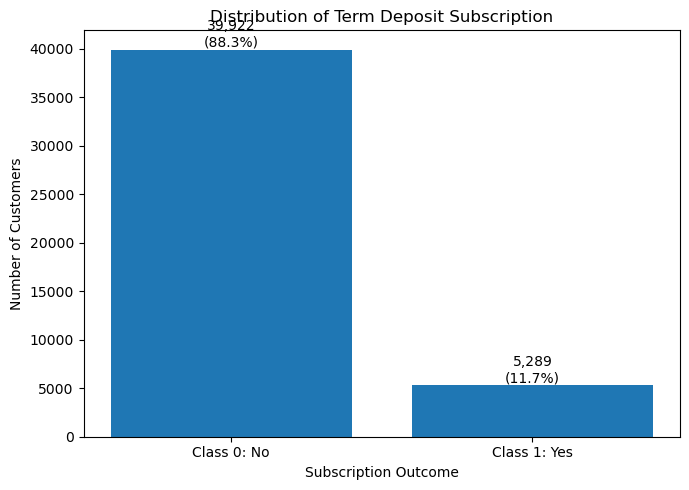

In [25]:
# Calculate target counts and percentages
target_counts = df["y"].value_counts().reindex(["no", "yes"])
target_percentages = (
    df["y"].value_counts(normalize=True).reindex(["no", "yes"]) * 100
)

# Plot target distribution
plt.figure(figsize=(7, 5))

class_labels = ["Class 0: No", "Class 1: Yes"]
bars = plt.bar(class_labels, target_counts.values)

plt.title("Distribution of Term Deposit Subscription")
plt.xlabel("Subscription Outcome")
plt.ylabel("Number of Customers")

for bar, count, percentage in zip(
    bars, target_counts.values, target_percentages.values
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({percentage:.1f}%)",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

The target variable is imbalanced. Class 0 contains 39,922 customers who did not subscribe, while Class 1 contains 5,289 customers who subscribed. This means 88.3% of the records belong to Class 0 and only 11.7% belong to Class 1. Because of this imbalance, accuracy alone may be misleading, so a stratified train-test split and metrics such as precision, recall and F1-score will be used.


### 2.3.1.2 Understanding distribution of features

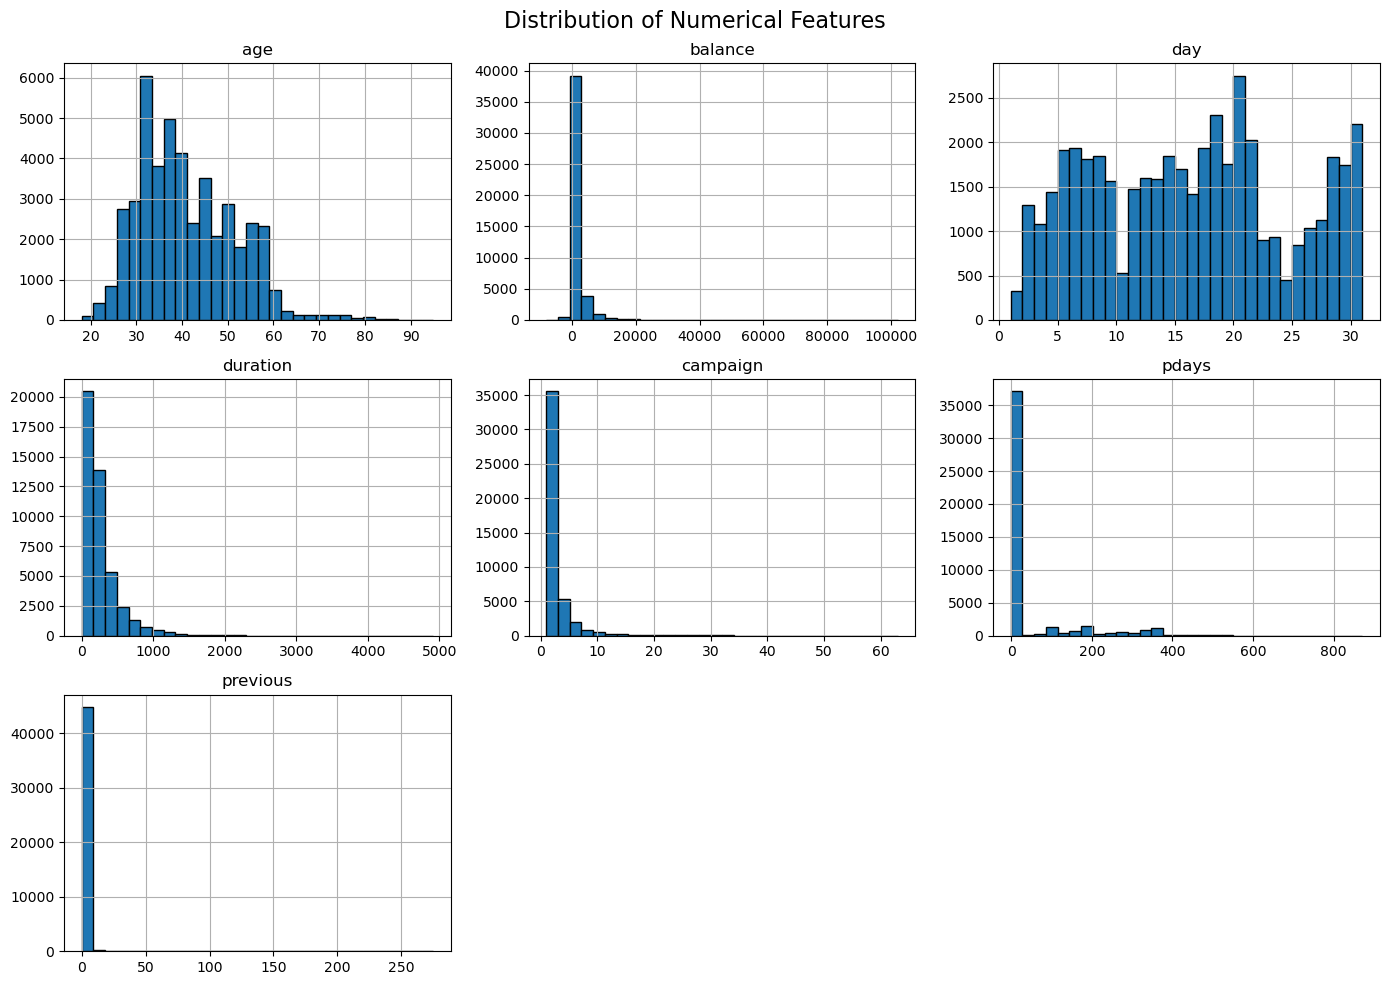

In [26]:
## Understanding distribution of features
# Select numerical features for distribution analysis
numerical_features = [
    "age", "balance", "day", "duration",
    "campaign", "pdays", "previous"
]

# Plot histograms for numerical features
df[numerical_features].hist(
    figsize=(14, 10),
    bins=30,
    edgecolor="black"
)

plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

Most customers are between 30 and 50 years old, while only a small number are above 60. "balance", "duration", "campaign" and "previous" are strongly right-skewed, with a small number of very large values. "pdays" is mostly concentrated at -1, showing that most customers were not contacted in an earlier campaign. These distributions suggest that outliers should be checked using boxplots, and transformations may be tested for the skewed features. "duration" will still be removed before modelling because it is only known after the call ends.

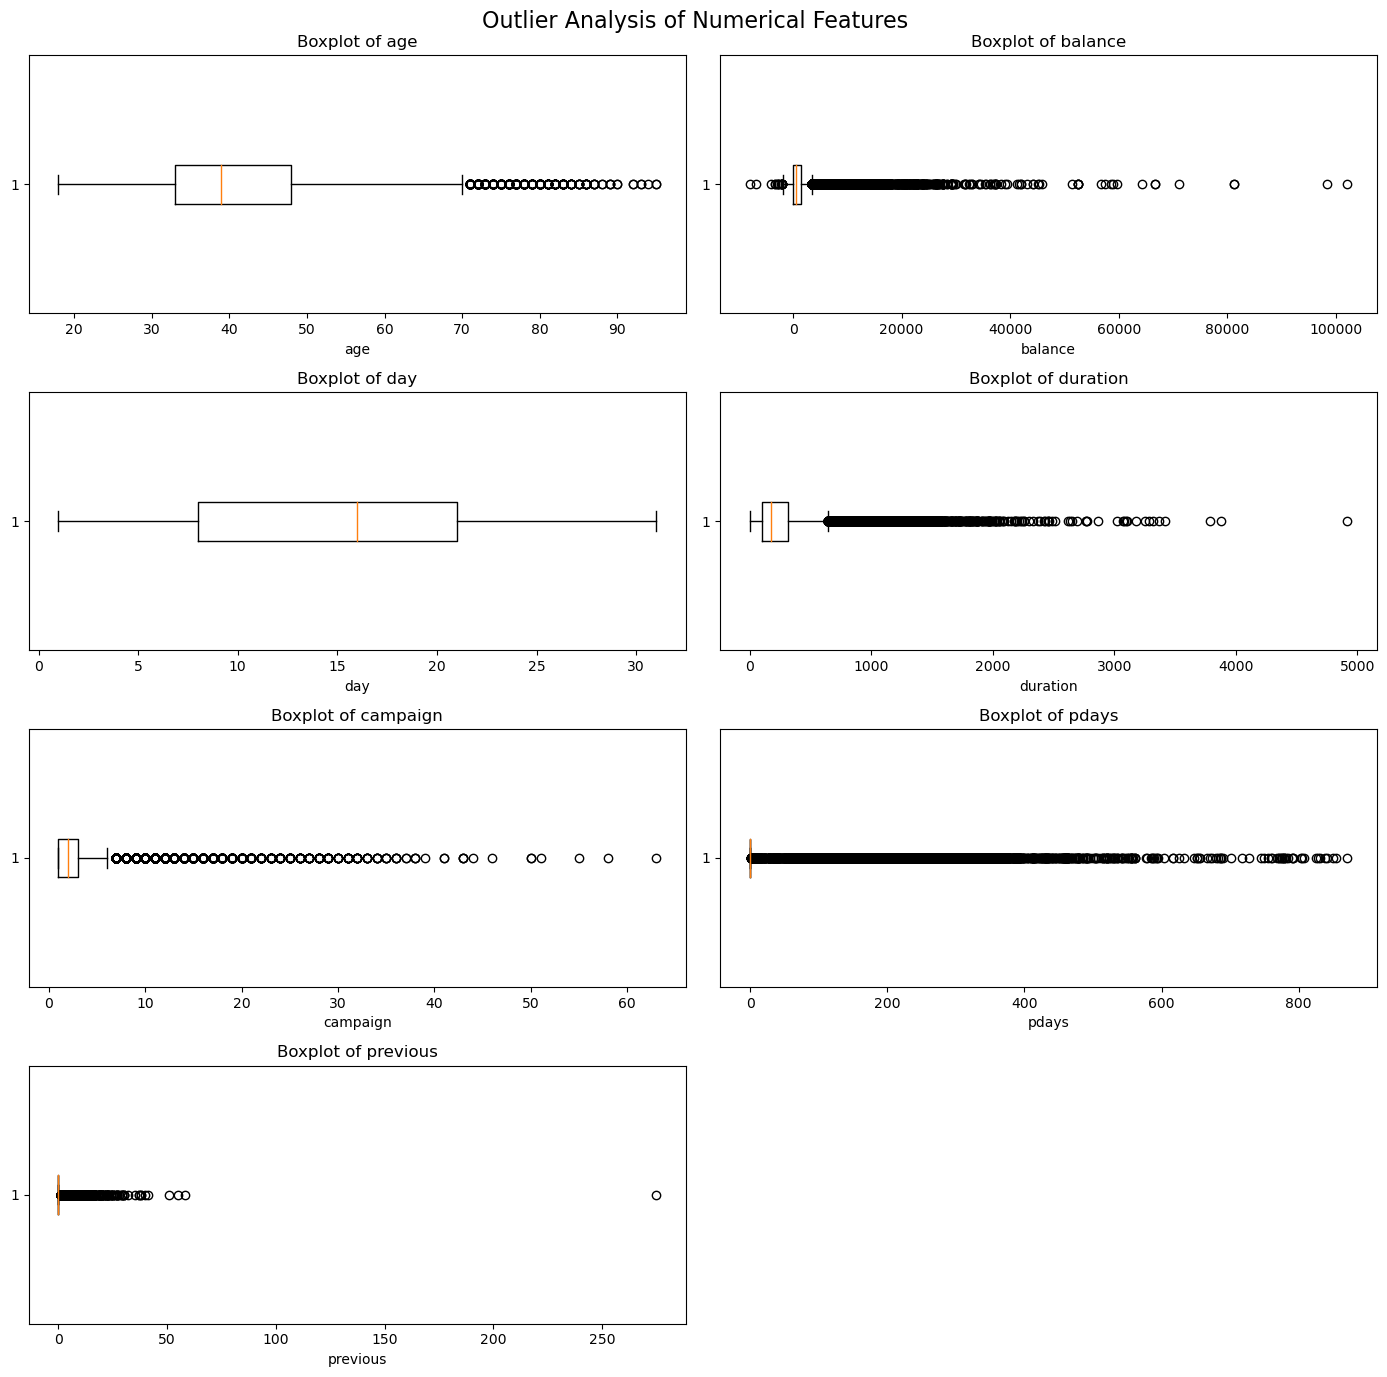

In [27]:
# Use boxplots to identify possible outliers in numerical features
fig, axes = plt.subplots(4, 2, figsize=(14, 14))
axes = axes.flatten()

for index, feature in enumerate(numerical_features):
    axes[index].boxplot(df[feature], vert=False)
    axes[index].set_title(f"Boxplot of {feature}")
    axes[index].set_xlabel(feature)

# Remove the unused final subplot
fig.delaxes(axes[-1])

plt.suptitle("Outlier Analysis of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()

The boxplots show possible outliers in "age", "balance", "duration", "campaign", "pdays" and "previous", while day has no clear outliers. The extreme values should not be removed automatically because they may represent genuine customer records. "balance", "campaign" and "previous" will be checked further during preprocessing, while "pdays" will be handled based on its special value of -1. "duration" will be excluded from the final model because it is only known after the call.

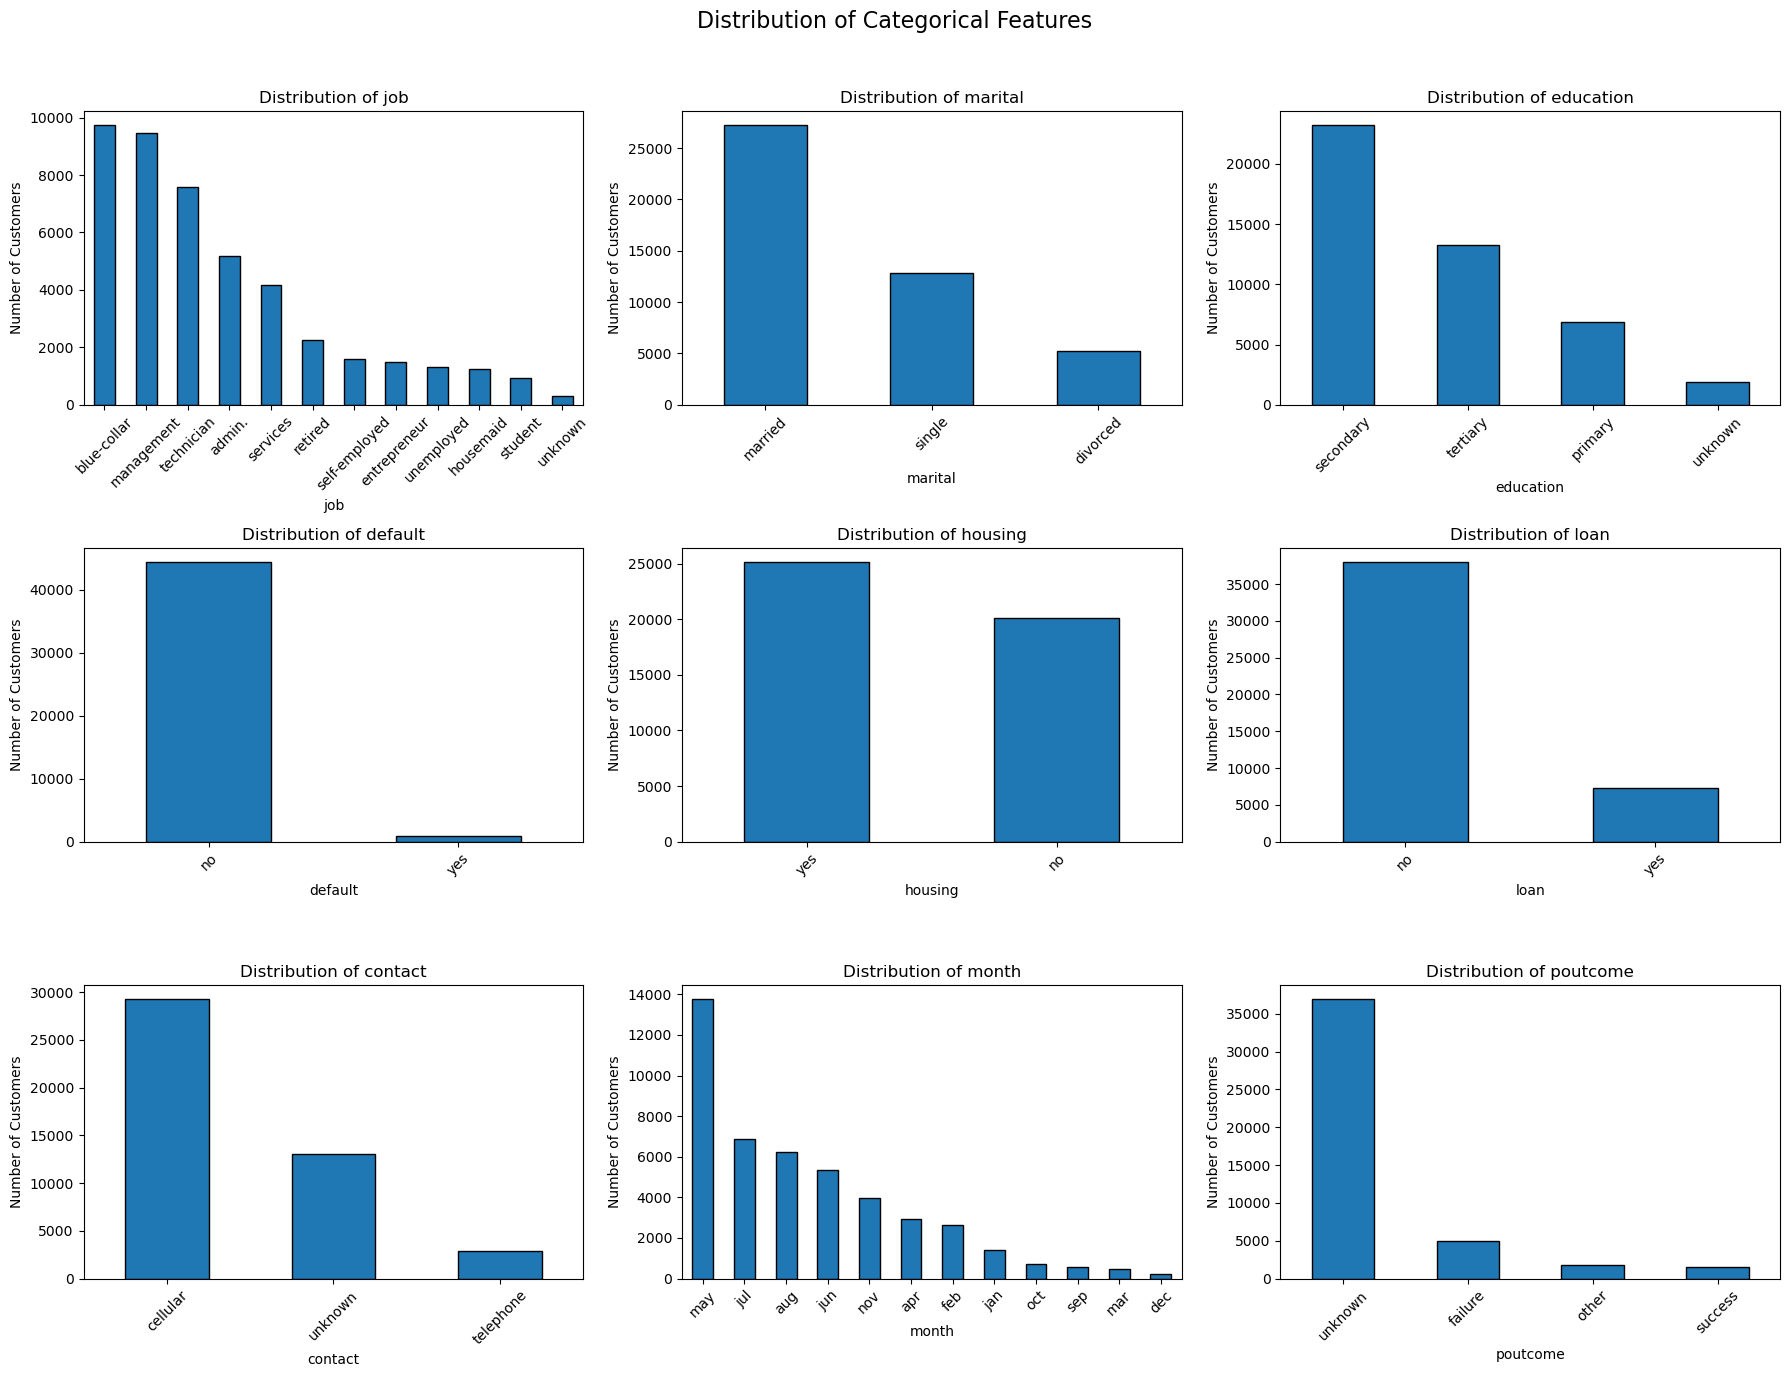

In [28]:
# Select categorical features, excluding the target variable
categorical_features = [
    "job", "marital", "education", "default",
    "housing", "loan", "contact", "month", "poutcome"
]

# Plot the distribution of categorical features
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for index, feature in enumerate(categorical_features):
    counts = df[feature].value_counts()
    counts.plot(kind="bar", ax=axes[index], edgecolor="black")

    axes[index].set_title(f"Distribution of {feature}")
    axes[index].set_xlabel(feature)
    axes[index].set_ylabel("Number of Customers")
    axes[index].tick_params(axis="x", rotation=45)

plt.suptitle("Distribution of Categorical Features", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

The dataset is dominated by married customers, customers with secondary education and customers without credit default or personal loans. Cellular contact is the most common contact method, while May has the highest number of campaign records. Several features, especially "contact", "education", "job" and "poutcome", contain "unknown" values. These will be kept as separate categories instead of being treated as standard missing values, and the categorical features will later be one-hot encoded for modelling.

### 2.3.2 Understanding relationship between variables

In [29]:
## Understanding relationship between variables
# Calculate the subscription rate for each previous campaign outcome
poutcome_subscription = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

poutcome_subscription

y,no,yes
poutcome,,
failure,87.390329,12.609671
other,83.315217,16.684783
success,35.274653,64.725347
unknown,90.838497,9.161503


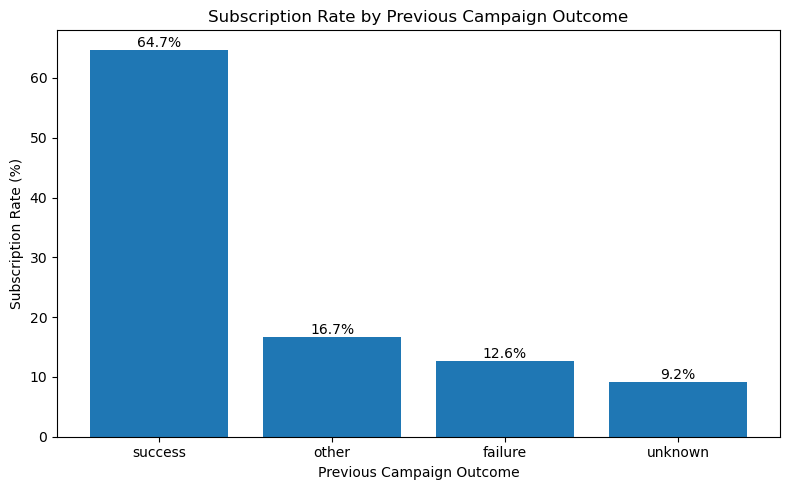

In [30]:
# Plot the percentage of customers who subscribed for each previous outcome
subscription_rate = poutcome_subscription["yes"].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(subscription_rate.index, subscription_rate.values)

plt.title("Subscription Rate by Previous Campaign Outcome")
plt.xlabel("Previous Campaign Outcome")
plt.ylabel("Subscription Rate (%)")

for bar, value in zip(bars, subscription_rate.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{value:.1f}%",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

Customers whose previous campaign outcome was successful had the highest subscription rate at 64.7%. This was much higher than the rates for “other”, “failure” and “unknown”, which ranged from 9.2% to 16.7%. This suggests that "poutcome" may be an important predictor, so it will be retained and one-hot encoded during preprocessing. The "unknown" category will also be kept because it represents customers without a clearly recorded previous outcome, and removing it would discard a large amount of potentially useful data.

# 3. Data Preparation

## 3.1 Data Cleaning

In [31]:
## Clean data
# Create a separate copy for modelling
df_model = df.copy()

# Remove call duration because it is only known after the call ends
df_model = df_model.drop(columns=["duration"])

# Convert pdays into clearer features
df_model["previously_contacted"] = (df_model["pdays"] != -1).astype(int)
df_model["days_since_previous_contact"] = df_model["pdays"].replace(-1, 0)

# Remove the original pdays column after feature engineering
df_model = df_model.drop(columns=["pdays"])

# Convert the target into numerical classes
df_model["y"] = df_model["y"].map({"no": 0, "yes": 1})

print("New dataset shape:", df_model.shape)
df_model.head()

New dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,campaign,previous,poutcome,y,previously_contacted,days_since_previous_contact
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,1,0,unknown,0,0,0
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,1,0,unknown,0,0,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,1,0,unknown,0,0,0
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,1,0,unknown,0,0,0
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,1,0,unknown,0,0,0


Longer calls may be associated with a higher subscription rate because interested customers are likely to remain engaged for longer. However, call duration is only known after the call has started and may partly reflect the subscription process itself. Since the model is intended to prioritise customers before contact, "duration" will be analysed during EDA but excluded from model training

## 3.2 Train-Test Split

In [32]:
## Split data into train set and test set
# Separate the input features from the target variable
X = df_model.drop(columns=["y"])
y = df_model["y"]

# Split the dataset into 80% training data and 20% testing data
# Stratification keeps the same target class proportions in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)

# Compare the class distribution in the training and testing sets
split_distribution = pd.DataFrame({
    "Training Count": y_train.value_counts().sort_index(),
    "Training Percentage (%)": y_train.value_counts(
        normalize=True
    ).sort_index() * 100,
    "Testing Count": y_test.value_counts().sort_index(),
    "Testing Percentage (%)": y_test.value_counts(
        normalize=True
    ).sort_index() * 100
})

split_distribution.index = [
    "No subscription (0)",
    "Subscription (1)"
]

split_distribution.round(2)

Training features shape: (36168, 16)
Testing features shape: (9043, 16)


,Training Count,Training Percentage (%),Testing Count,Testing Percentage (%)
No subscription (0),31937,88.3,7985,88.3
Subscription (1),4231,11.7,1058,11.7


The dataset was split into 80% training data and 20% testing data, providing 36,168 records for training and 9,043 records for testing. Stratification was used because only about 11.7% of customers subscribed to a term deposit. This keeps similar class proportions in both sets and allows the models to be compared fairly. A fixed random state was also used to make the split reproducible.

# 4. Modelling

4.1 Data Preprocessing

In [33]:
# Identify numerical and categorical input features
numerical_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()
categorical_features = X_train.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:", numerical_features)
print("\nCategorical features:", categorical_features)

# Scale numerical features and one-hot encode categorical features
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

Numerical features: ['age', 'balance', 'day', 'campaign', 'previous', 'previously_contacted', 'days_since_previous_contact']

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


### 4.2 Train Model

In [34]:
## Initialise and train model
# Train a baseline model that always predicts the majority class
baseline_model = DummyClassifier(
    strategy="most_frequent",
    random_state=42
)

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


In [35]:
# Logistic Regression pipeline
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Random Forest pipeline
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=100,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

# Train both models using the same training data
logistic_pipeline.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

random_forest_pipeline.fit(X_train, y_train)
print("Random Forest trained successfully.")

Logistic Regression trained successfully.
Random Forest trained successfully.


class_weight="balanced" was used because only 11.7% of customers subscribed. This gives more importance to the minority Class 1 and reduces the risk of the models mainly predicting Class 0.

# 5. Model Evaluation

In [36]:
## Evaluate model
# Store all trained models for fair comparison
models = {
    "Dummy Baseline": baseline_model,
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline
}

results = []

for model_name, model in models.items():
    # Generate predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    test_probabilities = model.predict_proba(X_test)[:, 1]

    # Record performance
    results.append({
        "Model": model_name,
        "Training F1": f1_score(
            y_train, train_predictions, zero_division=0
        ),
        "Test Accuracy": accuracy_score(
            y_test, test_predictions
        ),
        "Test Precision": precision_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test Recall": recall_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test F1": f1_score(
            y_test, test_predictions, zero_division=0
        ),
        "Test ROC-AUC": roc_auc_score(
            y_test, test_probabilities
        )
    })

# Create a model comparison table
model_results = pd.DataFrame(results)

model_results = model_results.sort_values(
    by="Test F1",
    ascending=False
).reset_index(drop=True)

model_results.round(3)

,Model,Training F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Logistic Regression,0.377,0.755,0.267,0.623,0.373,0.772
1,Random Forest,1.000,0.894,0.639,0.209,0.315,0.788
2,Dummy Baseline,0.000,0.883,0.000,0.000,0.000,0.500


The Dummy Baseline achieved 88.3% accuracy but failed to identify any customers who subscribed, showing that accuracy alone is misleading for this imbalanced dataset. Logistic Regression produced the highest test F1-score of 0.373 and recall of 0.623, meaning it identified more actual subscribers than Random Forest. Random Forest had higher precision but its training F1-score of 1.000 dropped to 0.315 on the test set, indicating overfitting. Therefore, Logistic Regression is currently the best-performing model and will be refined through hyperparameter tuning.

In [37]:
# Generate predictions from both trained models
logistic_predictions = logistic_pipeline.predict(X_test)
random_forest_predictions = random_forest_pipeline.predict(X_test)

print("Logistic Regression Classification Report")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["No Subscription", "Subscription"]
    )
)

print("Random Forest Classification Report")
print(
    classification_report(
        y_test,
        random_forest_predictions,
        target_names=["No Subscription", "Subscription"]
    )
)

Logistic Regression Classification Report
                 precision    recall  f1-score   support

No Subscription       0.94      0.77      0.85      7985
   Subscription       0.27      0.62      0.37      1058

       accuracy                           0.76      9043
      macro avg       0.60      0.70      0.61      9043
   weighted avg       0.86      0.76      0.79      9043

Random Forest Classification Report
                 precision    recall  f1-score   support

No Subscription       0.90      0.98      0.94      7985
   Subscription       0.64      0.21      0.31      1058

       accuracy                           0.89      9043
      macro avg       0.77      0.60      0.63      9043
   weighted avg       0.87      0.89      0.87      9043



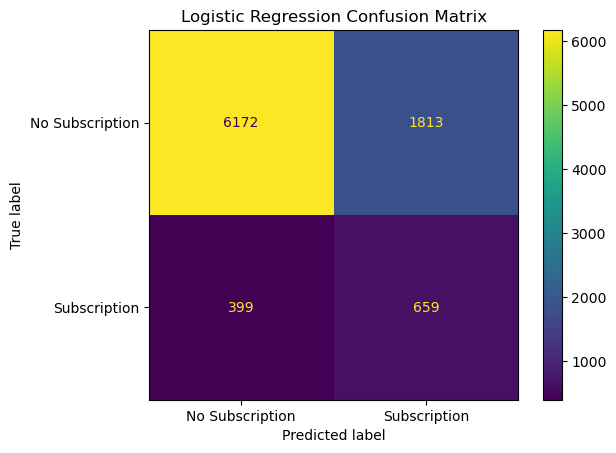

In [38]:
# Display Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["No Subscription", "Subscription"],
    values_format="d"
)

plt.title("Logistic Regression Confusion Matrix")
plt.show()

Logistic Regression correctly identified 659 out of 1,058 actual subscribers, giving a recall of 62.3%. However, it also predicted 1,813 non-subscribers as subscribers, which explains the low precision of 26.7%. Random Forest had higher precision at 63.9% but detected only 20.9% of actual subscribers. Since missing potential subscribers is important for this project, Logistic Regression currently provides the better balance and will be tuned to improve its F1-score.

5.2 Hyperparameter Tuning


In [39]:
# Define the Logistic Regression hyperparameters to test
# Each hyperparameter has no more than three possible values
logistic_param_grid = {
    "model__C": [0.01, 0.1, 1.0],
    "model__class_weight": [None, "balanced"]
}

# Use F1-score because both precision and recall matter
logistic_random_search = RandomizedSearchCV(
    estimator=logistic_pipeline,
    param_distributions=logistic_param_grid,
    n_iter=6,
    scoring="f1",
    cv=5,
    random_state=42,
    n_jobs=-1,
    return_train_score=True
)

# Tune using only the training data
logistic_random_search.fit(X_train, y_train)

print("Best parameters:", logistic_random_search.best_params_)
print("Best cross-validation F1-score:",
      round(logistic_random_search.best_score_, 3))

Best parameters: {'model__class_weight': 'balanced', 'model__C': 1.0}
Best cross-validation F1-score: 0.372


In [40]:
# Display the results of all tested hyperparameter combinations
tuning_results = pd.DataFrame(
    logistic_random_search.cv_results_
)[[
    "param_model__C",
    "param_model__class_weight",
    "mean_train_score",
    "mean_test_score",
    "rank_test_score"
]]

tuning_results = tuning_results.sort_values(
    by="rank_test_score"
).reset_index(drop=True)

tuning_results.round(3)

,param_model__C,param_model__class_weight,mean_train_score,mean_test_score,rank_test_score
0,1.0,balanced,0.377,0.372,1
1,0.1,balanced,0.375,0.370,2
2,0.01,balanced,0.369,0.368,3
3,1.0,None,0.275,0.277,4
4,0.1,None,0.267,0.266,5
5,0.01,None,0.221,0.219,6


5.3 Tuned Model Evaluation

In [41]:
# Retrieve the best tuned Logistic Regression pipeline
tuned_logistic_model = logistic_random_search.best_estimator_

# Generate predictions using the tuned model
tuned_train_predictions = tuned_logistic_model.predict(X_train)
tuned_test_predictions = tuned_logistic_model.predict(X_test)
tuned_test_probabilities = tuned_logistic_model.predict_proba(X_test)[:, 1]

# Compare the original and tuned Logistic Regression models
logistic_comparison = pd.DataFrame({
    "Model": ["Original Logistic Regression", "Tuned Logistic Regression"],
    "Training F1": [
        f1_score(y_train, logistic_pipeline.predict(X_train)),
        f1_score(y_train, tuned_train_predictions)
    ],
    "Test Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, tuned_test_predictions)
    ],
    "Test Precision": [
        precision_score(y_test, logistic_predictions),
        precision_score(y_test, tuned_test_predictions)
    ],
    "Test Recall": [
        recall_score(y_test, logistic_predictions),
        recall_score(y_test, tuned_test_predictions)
    ],
    "Test F1": [
        f1_score(y_test, logistic_predictions),
        f1_score(y_test, tuned_test_predictions)
    ],
    "Test ROC-AUC": [
        roc_auc_score(
            y_test,
            logistic_pipeline.predict_proba(X_test)[:, 1]
        ),
        roc_auc_score(y_test, tuned_test_probabilities)
    ]
})

logistic_comparison.round(3)

,Model,Training F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC-AUC
0,Original Logistic Regression,0.377,0.755,0.267,0.623,0.373,0.772
1,Tuned Logistic Regression,0.377,0.755,0.267,0.623,0.373,0.772


Tuned Logistic Regression Classification Report
                 precision    recall  f1-score   support

No Subscription       0.94      0.77      0.85      7985
   Subscription       0.27      0.62      0.37      1058

       accuracy                           0.76      9043
      macro avg       0.60      0.70      0.61      9043
   weighted avg       0.86      0.76      0.79      9043



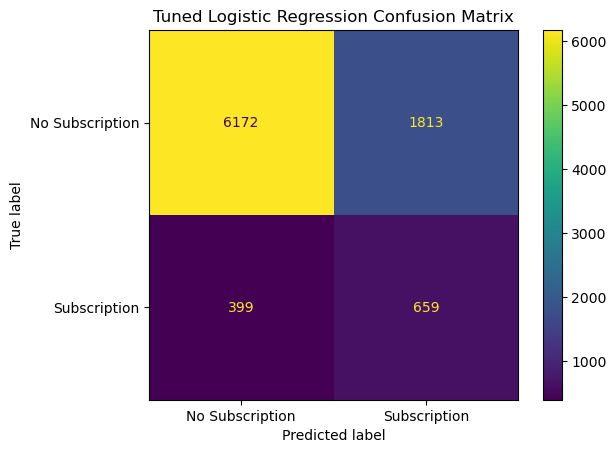

In [42]:
print("Tuned Logistic Regression Classification Report")

print(
    classification_report(
        y_test,
        tuned_test_predictions,
        target_names=["No Subscription", "Subscription"]
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_test,
    tuned_test_predictions,
    display_labels=["No Subscription", "Subscription"],
    values_format="d"
)

plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()

In [43]:
## New data

## Predict


## Iterative model development


6.1 Feature Engineering Comparison

In [44]:
## Further feature engineering / feature selection
# Compare original pdays with the engineered pdays features
raw_df = df.drop(columns=["duration"]).copy()
raw_df["y"] = raw_df["y"].map({"no": 0, "yes": 1})

X_raw = raw_df.drop(columns=["y"])
X_train_raw = X_raw.loc[X_train.index]
X_test_raw = X_raw.loc[X_test.index]

raw_num = X_train_raw.select_dtypes(include=np.number).columns
raw_cat = X_train_raw.select_dtypes(include="object").columns

raw_preprocessor = ColumnTransformer([
    ("num", StandardScaler(), raw_num),
    ("cat", OneHotEncoder(handle_unknown="ignore"), raw_cat)
])

raw_model = Pipeline([
    ("preprocessor", raw_preprocessor),
    ("model", LogisticRegression(
        C=1.0,
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    ))
])

raw_model.fit(X_train_raw, y_train)
raw_predictions = raw_model.predict(X_test_raw)

comparison = pd.DataFrame({
    "Feature Set": ["Original pdays", "Engineered pdays features"],
    "Precision": [
        precision_score(y_test, raw_predictions),
        precision_score(y_test, tuned_test_predictions)
    ],
    "Recall": [
        recall_score(y_test, raw_predictions),
        recall_score(y_test, tuned_test_predictions)
    ],
    "F1-score": [
        f1_score(y_test, raw_predictions),
        f1_score(y_test, tuned_test_predictions)
    ]
})

comparison.round(3)

,Feature Set,Precision,Recall,F1-score
0,Original pdays,0.267,0.624,0.374
1,Engineered pdays features,0.267,0.623,0.373


The engineered "pdays" features did not improve model performance. The original "pdays" feature achieved a slightly higher F1-score of 0.374, so it will be retained in the final model. This comparison shows that feature engineering was tested and selected based on evidence rather than assumption.

6.2 Decision Threshold Testing

In [46]:
# Generate cross-validated probabilities using only training data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_probabilities = cross_val_predict(
    raw_model,
    X_train_raw,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

# Compare different classification thresholds
threshold_results = []

for threshold in np.arange(0.30, 0.81, 0.05):
    predictions = (cv_probabilities >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_train, predictions),
        "Recall": recall_score(y_train, predictions),
        "F1-score": f1_score(y_train, predictions)
    })

threshold_table = pd.DataFrame(threshold_results)
threshold_table.round(3)

,Threshold,Precision,Recall,F1-score
0,0.30,0.149,0.899,0.255
1,0.35,0.164,0.853,0.275
2,0.40,0.188,0.789,0.303
3,0.45,0.219,0.706,0.334
4,0.50,0.266,0.622,0.373
5,0.55,0.329,0.549,0.411
6,0.60,0.395,0.487,0.437
7,0.65,0.448,0.425,0.436
8,0.70,0.496,0.369,0.423
9,0.75,0.523,0.324,0.400


In [47]:
best_threshold = threshold_table.loc[
    threshold_table["F1-score"].idxmax(),
    "Threshold"
]

print("Best threshold:", round(best_threshold, 2))

Best threshold: 0.6


    A threshold of 0.60 produced the highest cross-validation F1-score of 0.437. Raising the threshold reduced false positive predictions while maintaining a reasonable recall, so 0.60 was selected using only the training data.

                 precision    recall  f1-score   support

No Subscription       0.93      0.90      0.92      7985
   Subscription       0.40      0.48      0.44      1058

       accuracy                           0.85      9043
      macro avg       0.66      0.69      0.68      9043
   weighted avg       0.87      0.85      0.86      9043



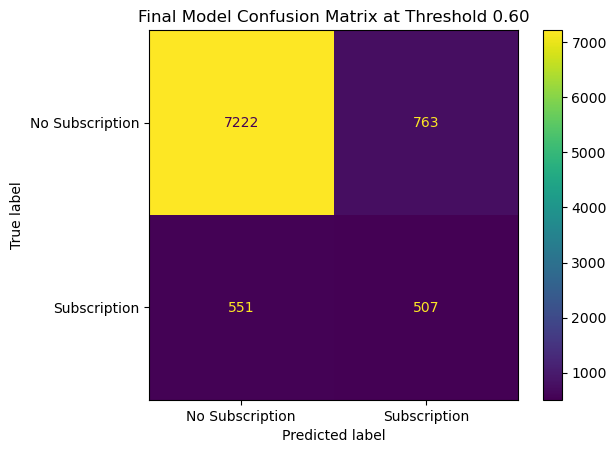

Final test F1-score: 0.436


In [48]:
# Apply the selected threshold to the unseen test data
final_probabilities = raw_model.predict_proba(X_test_raw)[:, 1]
final_predictions = (final_probabilities >= best_threshold).astype(int)

print(classification_report(
    y_test,
    final_predictions,
    target_names=["No Subscription", "Subscription"]
))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    final_predictions,
    display_labels=["No Subscription", "Subscription"],
    values_format="d"
)

plt.title("Final Model Confusion Matrix at Threshold 0.60")
plt.show()

print("Final test F1-score:",
      round(f1_score(y_test, final_predictions), 3))

Using a threshold of 0.60 improved the final test F1-score to 0.436. The model correctly identified 507 subscribers, while false positive predictions were reduced from 1,813 to 763. Although recall decreased, precision improved, giving a better overall balance for customer prioritisation.

6.3 Final Model Selection

Logistic Regression using the original "pdays" feature and a prediction threshold of 0.60 was selected as the final model. It achieved the highest test F1-score of 0.436 and showed similar cross-validation performance, suggesting that it generalises well to unseen data.

In [51]:
# Select one unseen customer from the test set
sample_index = X_test_raw.index[0]
new_customer = X_test_raw.loc[[sample_index]]

# Predict subscription probability using the final threshold
subscription_probability = raw_model.predict_proba(new_customer)[:, 1][0]
predicted_class = int(subscription_probability >= best_threshold)
actual_class = y_test.loc[sample_index]

print("Predicted class:", predicted_class)
print("Subscription probability:", round(subscription_probability, 3))
print("Actual class:", actual_class)

Predicted class: 0
Subscription probability: 0.107
Actual class: 0


7 Save Final Model

In [53]:
# Refit the selected model using all available data for deployment
final_deployment_model = clone(raw_model)
final_deployment_model.fit(X_raw, y)

# Save the model, threshold and expected feature columns
model_package = {
    "model": final_deployment_model,
    "threshold": float(best_threshold),
    "feature_columns": X_raw.columns.tolist()
}

joblib.dump(model_package, "callsmart_model.joblib")

print("Final model saved successfully.")

Final model saved successfully.
